# Classification

It's a problem of predicting is the input is something or belongs to a class or not.

There are three types:
- Binary Classification: Predict if the input belongs to class A or B.
- Multiclass Classification: Predict if the input belongs to one of n possible classes.
- Multi labeled classification: Predict all the possible classes/labels that the input belongs to. e.g.: An article can have various labels inlcluding CS, AI, Mathematics, Learning, etc.

## 1. Make Classification Data

In [1]:
from sklearn.datasets import make_circles

n_samples = 1000
X, y = make_circles(n_samples, noise=0.03, random_state=42)

In [2]:
len(X), len(y)

(1000, 1000)

In [3]:
X[:5], y[:5]

(array([[ 0.75424625,  0.23148074],
        [-0.75615888,  0.15325888],
        [-0.81539193,  0.17328203],
        [-0.39373073,  0.69288277],
        [ 0.44220765, -0.89672343]]),
 array([1, 1, 1, 1, 0]))

In [4]:
# make DataFrame of Circle Data
import pandas as pd

circles = pd.DataFrame({"X1": X[:, 0], "X2": X[:, 1], "label": y})
circles

,X1,X2,label
0,0.754246,0.231481,1
1,-0.756159,0.153259,1
2,-0.815392,0.173282,1
3,-0.393731,0.692883,1
4,0.442208,-0.896723,0
...,...,...,...
995,0.244054,0.944125,0
996,-0.978655,-0.272373,0
997,-0.136900,-0.810012,1
998,0.670362,-0.767502,0


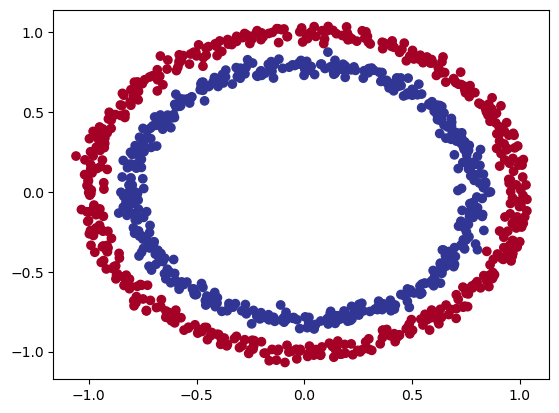

In [5]:
# Visualize
import matplotlib.pyplot as plt

plt.scatter(
    x=X[:, 0],
    y=X[:, 1],
    c=y,
    cmap=plt.cm.RdYlBu
)

### 1.1 Check Input & Output Shapes

In [6]:
X.shape, y.shape

((1000, 2), (1000,))

In [7]:
# View first example of features & labels
X_sample = X[0]
y_sample = y[0]

X_sample, y_sample, X_sample.shape, y_sample.shape

(array([0.75424625, 0.23148074]), np.int64(1), (2,), ())

### 1.2 Turn into Tensors & Creating train-test split

In [8]:
import torch

In [9]:
X = torch.from_numpy(X).type(torch.float)
y = torch.from_numpy(y).type(torch.float)

In [10]:
X[:5], y[:5]

(tensor([[ 0.7542,  0.2315],
         [-0.7562,  0.1533],
         [-0.8154,  0.1733],
         [-0.3937,  0.6929],
         [ 0.4422, -0.8967]]),
 tensor([1., 1., 1., 1., 0.]))

In [11]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

In [12]:
X_train[:5], y_train[:5]

(tensor([[ 0.6288,  0.3657],
         [-0.0597, -0.9970],
         [-0.9314, -0.4297],
         [-0.0701,  0.7812],
         [ 1.0050,  0.0125]]),
 tensor([1., 0., 0., 1., 0.]))

In [13]:
len(X_train), len(X_test)

(800, 200)

## 2. Building Model

In [14]:
from torch import nn

device = "cuda" if torch.cuda.is_available() else "cpu"
device

'cuda'

In [15]:
class CircleModelV0(nn.Module):
    def __init__(self):
        super().__init__()
        self.layer1 = nn.Linear(in_features=2, out_features=5) # Takes 2 inputs & upscales it to 5 features
        self.layer2 = nn.Linear(in_features=5, out_features=1) # takes 5 features from previous layer & outputs a single feature

    def forward(self, x):
        return self.layer2(self.layer1(x)) # x -> Layer1 -> Layer2

In [16]:
model_0 = CircleModelV0().to(device)
model_0

CircleModelV0(
  (layer1): Linear(in_features=2, out_features=5, bias=True)
  (layer2): Linear(in_features=5, out_features=1, bias=True)
)

In [17]:
model_0.state_dict()

OrderedDict([('layer1.weight',
              tensor([[ 0.6147,  0.2656],
                      [ 0.4029,  0.5730],
                      [-0.2432,  0.2152],
                      [ 0.1144,  0.6473],
                      [-0.4337,  0.6832]], device='cuda:0')),
             ('layer1.bias',
              tensor([ 0.5634,  0.0480,  0.5652, -0.3114, -0.4326], device='cuda:0')),
             ('layer2.weight',
              tensor([[-0.3006,  0.2659, -0.2397,  0.1438,  0.3251]], device='cuda:0')),
             ('layer2.bias', tensor([0.1421], device='cuda:0'))])

In [18]:
next(model_0.parameters()).device

device(type='cuda', index=0)

### We can replicate the model in a simpler way using `nn.Sequential()`

In [19]:
model_1 = nn.Sequential(
    nn.Linear(in_features=2, out_features=5),
    nn.Linear(in_features=5, out_features=1)
).to(device)

model_1

Sequential(
  (0): Linear(in_features=2, out_features=5, bias=True)
  (1): Linear(in_features=5, out_features=1, bias=True)
)

In [20]:
model_1.state_dict()

OrderedDict([('0.weight',
              tensor([[-0.2641, -0.2063],
                      [ 0.4231,  0.1417],
                      [ 0.0552, -0.1720],
                      [-0.5692,  0.2008],
                      [ 0.2045, -0.6399]], device='cuda:0')),
             ('0.bias',
              tensor([ 0.6594,  0.4310,  0.4143, -0.6423,  0.5686], device='cuda:0')),
             ('1.weight',
              tensor([[-0.2380,  0.0532, -0.3319, -0.0137,  0.3708]], device='cuda:0')),
             ('1.bias', tensor([-0.1309], device='cuda:0'))])

In [21]:
next(model_1.parameters()).device

device(type='cuda', index=0)

In [22]:
# make prediction
with torch.inference_mode():
    untrained_preds = model_1(X_test.to(device))

untrained_preds.shape, len(untrained_preds), untrained_preds[:10], y_test[:10]

(torch.Size([200, 1]),
 200,
 tensor([[-0.0192],
         [-0.1843],
         [-0.2384],
         [-0.3219],
         [-0.0391],
         [-0.1153],
         [-0.0030],
         [-0.3251],
         [-0.0008],
         [-0.3734]], device='cuda:0'),
 tensor([1., 1., 0., 1., 1., 1., 0., 1., 0., 0.]))

### 2.1 Setup Loss Function & Optimizer

which Loss Function & Optimizer to use entirely depends upon the type of problem

Common Loss:
- Regression: MAE or MSE
- Classification: Cross Entropy or Binary Cross Entropy

Common Optimizers:
- SGD
- Adam

In [23]:
# loss_fn = nn.BCELoss() # Requires inputs to have gone through Sigmoid Activation function
loss_fn = nn.BCEWithLogitsLoss() # Sigmoid activation function is built-in | more numerically stable

optimizer = torch.optim.SGD(params=model_1.parameters(), lr=0.1)

In [24]:
loss_fn, optimizer

(BCEWithLogitsLoss(),
 SGD (
 Parameter Group 0
     dampening: 0
     differentiable: False
     foreach: None
     fused: None
     lr: 0.1
     maximize: False
     momentum: 0
     nesterov: False
     weight_decay: 0
 ))

In [25]:
# Aclculate accuracy. What percentage of predictions does our model gets correct?
def accuracy_fn(y_true, y_pred):
    correct = torch.eq(y_true, y_pred).sum().item()
    return (correct / len(y_pred)) * 100

## 3. Train the Model

Steps to Train the Model:
1. Set model to train mode
2. make predictions / Feed-Forward
3. calculate loss
4. zero grad
5. backpropagation
6. gradient descent

### 3.1 Going from raw logits -> prediction probabilities -> prediction labels

Our model outputs are going to be raw **logits**.

We can convert the **logits** into **prediction probabilities** by passing them to some kind of activation function (e.g.: **Sigmoid** for binary classification and **Softmax** for multi-class classification)

Then we can convert our model's prediction probabilities to **prediction label** by either rounding them or taking the `argmax()`

In [26]:
# View first 5 outputs of the forward pass
model_1.eval()
with torch.inference_mode():
    y_logits = model_1(X_test.to(device))[:5]
y_logits, y_test[:5]

(tensor([[-0.0192],
         [-0.1843],
         [-0.2384],
         [-0.3219],
         [-0.0391]], device='cuda:0'),
 tensor([1., 1., 0., 1., 1.]))

In [27]:
# Use Sigmoid activation function on our model logits to turn them into prediction probabilities
y_pred_probs = torch.sigmoid(y_logits)
y_pred_probs

tensor([[0.4952],
        [0.4541],
        [0.4407],
        [0.4202],
        [0.4902]], device='cuda:0')

For the prediction probability values, we need to perform a range-style rounding on them:
- `y_pred_probs` >= 0.5, `y=1` (class 1)
- `y_pred_probs` < 0.5, `y=0` (class 0)

In [28]:
# Find the predicted labels
y_preds = torch.round(y_pred_probs)
y_preds

tensor([[0.],
        [0.],
        [0.],
        [0.],
        [0.]], device='cuda:0')

In [29]:
# Full implementation in one
y_pred_labels = torch.round(torch.sigmoid(model_1(X_test.to(device)[:5])))
y_pred_labels

tensor([[0.],
        [0.],
        [0.],
        [0.],
        [0.]], device='cuda:0', grad_fn=<RoundBackward0>)

In [30]:
# Check for equality
print(torch.eq(y_preds.squeeze(), y_pred_labels.squeeze()))

# get rid of extra dimension
y_preds.squeeze()

tensor([True, True, True, True, True], device='cuda:0')


tensor([0., 0., 0., 0., 0.], device='cuda:0')

### 3.2 Building a Training & Test Loop

In [31]:
epochs = 100

steps = []
train_losses = []
test_losses = []
train_accs = []
test_accs = []

X_train, y_train = X_train.to(device), y_train.to(device)
X_test, y_test = X_test.to(device), y_test.to(device)

for epoch in range(epochs):
    model_1.train()

    logits = model_1(X_train).squeeze()
    y_preds = torch.round(torch.sigmoid(logits)) # Logit -> Pred Probabilities -> Pred Labels
    loss = loss_fn(logits, y_train)
    acc = accuracy_fn(y_true=y_train, y_pred=y_preds)
    
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    # Testing
    if epoch % 10 == 0:
        model_1.eval()
        with torch.inference_mode():
            logits = model_1(X_test).squeeze()
            y_preds = torch.round(torch.sigmoid(logits))
            test_loss = loss_fn(logits, y_test)
            test_acc = accuracy_fn(y_true=y_test, y_pred=y_preds)
        steps.append(epoch)
        train_losses.append(loss.item())
        test_losses.append(test_loss.item())
        train_accs.append(acc)
        test_accs.append(test_acc)

        print(f"Epoch: {epoch} \n\tLoss:\n\t\t Train: {loss} | Test: {test_loss}\n\tAccuracy:\n\t\tTrain: {acc} | Test: {test_acc}")

Epoch: 0 
	Loss:
		 Train: 0.7001957297325134 | Test: 0.695938766002655
	Accuracy:
		Train: 43.75 | Test: 42.0
Epoch: 10 
	Loss:
		 Train: 0.6958841681480408 | Test: 0.6979695558547974
	Accuracy:
		Train: 49.0 | Test: 47.0
Epoch: 20 
	Loss:
		 Train: 0.6947255730628967 | Test: 0.6995493173599243
	Accuracy:
		Train: 51.0 | Test: 45.5
Epoch: 30 
	Loss:
		 Train: 0.6942973732948303 | Test: 0.7002553939819336
	Accuracy:
		Train: 50.74999999999999 | Test: 47.0
Epoch: 40 
	Loss:
		 Train: 0.6940574645996094 | Test: 0.7004247307777405
	Accuracy:
		Train: 51.24999999999999 | Test: 48.0
Epoch: 50 
	Loss:
		 Train: 0.6938807368278503 | Test: 0.7003304958343506
	Accuracy:
		Train: 51.0 | Test: 48.5
Epoch: 60 
	Loss:
		 Train: 0.6937359571456909 | Test: 0.700124204158783
	Accuracy:
		Train: 51.125 | Test: 47.5
Epoch: 70 
	Loss:
		 Train: 0.6936131119728088 | Test: 0.6998804211616516
	Accuracy:
		Train: 51.125 | Test: 47.0
Epoch: 80 
	Loss:
		 Train: 0.6935076713562012 | Test: 0.6996334195137024
	A

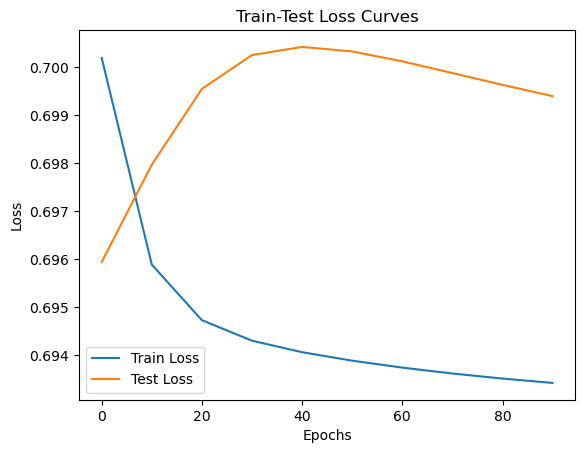

In [32]:
import numpy as np
plt.plot(steps, train_losses, label="Train Loss")
plt.plot(steps, test_losses, label="Test Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Train-Test Loss Curves")
plt.legend()
plt.show();

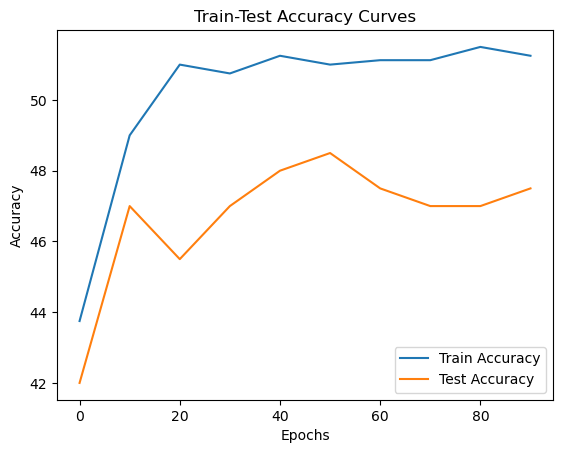

In [33]:
plt.plot(steps, train_accs, label="Train Accuracy")
plt.plot(steps, test_accs, label="Test Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.title("Train-Test Accuracy Curves")
plt.legend()
plt.show();

## 4. Make predictions and evaluate the model

Form the metrics and visualization the model isn't learning much.

So let's inspect with predictions & Visualization 

We'll use `plot_decision_boundary`

In [34]:
import requests
from pathlib import Path

FILE_NAME = "helper_functions.py"
# Download the helper fucntion
if not Path(FILE_NAME).is_file():
    req = requests.get("https://raw.githubusercontent.com/mrdbourke/pytorch-deep-learning/refs/heads/main/helper_functions.py")
    with open(FILE_NAME, "wb") as f:
        f.write(req.content)

In [35]:
from helper_functions import plot_predictions, plot_decision_boundary

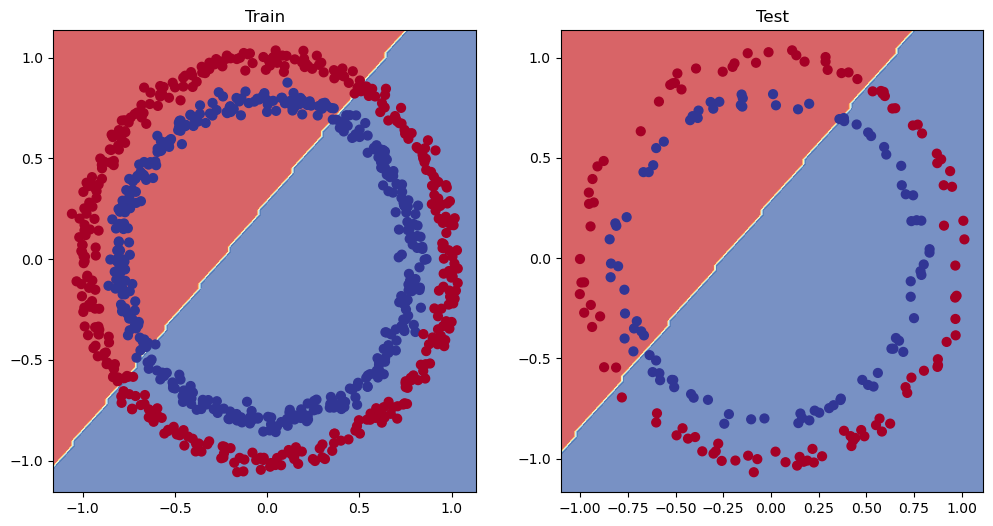

In [36]:
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.title("Train")
plot_decision_boundary(model_1, X_train, y_train)

plt.subplot(1, 2, 2)
plt.title("Test")
plot_decision_boundary(model_1, X_test, y_test)

## 5. Improving the model

- Add more layers: Gives the model more chances to learn about patterns in the data.
- Add more hidden units/neurons: we can go from 5 to 10 neurons allowing it to learn more.
- Fit for longer
- Changing the activation functions
- Change the Learning rate
- Change the loss function

These all options are from a model's perspective because they deal directly with the model, rather than the data.

All these changes are the values that we can manually change/adjust, they are referred to as **Hyperparameters** 

Let's try to improve the model by:
- Adding more hidden units: 5 -> 10
- Increasing the number of layers: 2 -> 3
- Increasing the number of epochs from 100 -> 1000

In [37]:
class CircleModelV1(nn.Module):
    def __init__(self):
        super().__init__()
        self.layer_1 = nn.Linear(in_features=2, out_features=10)
        self.layer_2 = nn.Linear(in_features=10, out_features=10)
        self.layer_3 = nn.Linear(in_features=10, out_features=1)

    def forward(self, x):
        return self.layer_3(self.layer_2(self.layer_1(x)))

In [38]:
model_2 = CircleModelV1().to(device)
model_2

CircleModelV1(
  (layer_1): Linear(in_features=2, out_features=10, bias=True)
  (layer_2): Linear(in_features=10, out_features=10, bias=True)
  (layer_3): Linear(in_features=10, out_features=1, bias=True)
)

In [39]:
model_2.state_dict()

OrderedDict([('layer_1.weight',
              tensor([[ 0.2324, -0.1102],
                      [ 0.3890,  0.3490],
                      [-0.0719, -0.4533],
                      [-0.6288, -0.1460],
                      [-0.3199, -0.5943],
                      [ 0.6316,  0.4821],
                      [-0.4724,  0.1087],
                      [-0.3475, -0.3771],
                      [ 0.2756, -0.5979],
                      [ 0.3443, -0.0216]], device='cuda:0')),
             ('layer_1.bias',
              tensor([ 0.6870,  0.5899, -0.1950,  0.4563, -0.2250,  0.4073,  0.3376, -0.2083,
                      -0.0039,  0.5051], device='cuda:0')),
             ('layer_2.weight',
              tensor([[-0.1604,  0.2167,  0.0480, -0.2537, -0.1159,  0.1752, -0.2220, -0.3068,
                        0.2328, -0.2374],
                      [ 0.2490,  0.1919, -0.3157, -0.2263, -0.2672,  0.2024, -0.1878, -0.0703,
                       -0.2760, -0.1542],
                      [-0.3134, -0.007

In [40]:
next(model_2.parameters()).device

device(type='cuda', index=0)

In [41]:
# loss_fn = nn.BCELoss() # Requires inputs to have gone through Sigmoid Activation function
loss_fn = nn.BCEWithLogitsLoss() # Sigmoid activation function is built-in | more numerically stable

optimizer = torch.optim.SGD(params=model_2.parameters(), lr=0.1)

In [42]:
epochs = 2000

steps = []
train_losses = []
test_losses = []
train_accs = []
test_accs = []

X_train, y_train = X_train.to(device), y_train.to(device)
X_test, y_test = X_test.to(device), y_test.to(device)

for epoch in range(epochs):
    model_1.train()

    logits = model_2(X_train).squeeze()
    y_preds = torch.round(torch.sigmoid(logits)) # Logit -> Pred Probabilities -> Pred Labels
    loss = loss_fn(logits, y_train)
    acc = accuracy_fn(y_true=y_train, y_pred=y_preds)
    
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    # Testing
    if epoch % 100 == 0:
        model_1.eval()
        with torch.inference_mode():
            logits = model_2(X_test).squeeze()
            y_preds = torch.round(torch.sigmoid(logits))
            test_loss = loss_fn(logits, y_test)
            test_acc = accuracy_fn(y_true=y_test, y_pred=y_preds)
        steps.append(epoch)
        train_losses.append(loss.item())
        test_losses.append(test_loss.item())
        train_accs.append(acc)
        test_accs.append(test_acc)

        print(f"Epoch: {epoch} \n\tLoss:\n\t\t Train: {loss} | Test: {test_loss}\n\tAccuracy:\n\t\tTrain: {acc} | Test: {test_acc}")

Epoch: 0 
	Loss:
		 Train: 0.6928744316101074 | Test: 0.6951240301132202
	Accuracy:
		Train: 51.0 | Test: 46.0
Epoch: 100 
	Loss:
		 Train: 0.6927911043167114 | Test: 0.696062445640564
	Accuracy:
		Train: 53.25 | Test: 47.0
Epoch: 200 
	Loss:
		 Train: 0.6927770972251892 | Test: 0.6963542699813843
	Accuracy:
		Train: 59.875 | Test: 52.0
Epoch: 300 
	Loss:
		 Train: 0.6927740573883057 | Test: 0.696492075920105
	Accuracy:
		Train: 57.62500000000001 | Test: 51.5
Epoch: 400 
	Loss:
		 Train: 0.6927732825279236 | Test: 0.696557879447937
	Accuracy:
		Train: 56.125 | Test: 51.0
Epoch: 500 
	Loss:
		 Train: 0.6927731037139893 | Test: 0.6965891122817993
	Accuracy:
		Train: 55.75 | Test: 50.5
Epoch: 600 
	Loss:
		 Train: 0.6927731037139893 | Test: 0.6966040134429932
	Accuracy:
		Train: 55.50000000000001 | Test: 51.0
Epoch: 700 
	Loss:
		 Train: 0.6927731037139893 | Test: 0.6966109871864319
	Accuracy:
		Train: 55.625 | Test: 51.0
Epoch: 800 
	Loss:
		 Train: 0.6927730441093445 | Test: 0.696614205

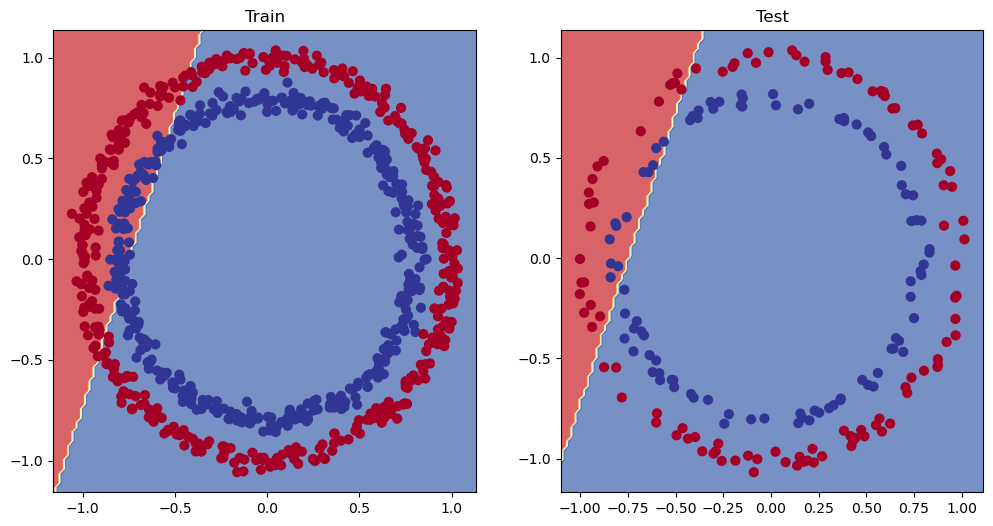

In [43]:
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.title("Train")
plot_decision_boundary(model_2, X_train, y_train)

plt.subplot(1, 2, 2)
plt.title("Test")
plot_decision_boundary(model_2, X_test, y_test)

### 5.1 Let's verify the models capabilities

Even after all the changes the model is basically performing the same so, let's try to verify its capabilities with some simple straight line data

In [44]:
known_weights = 0.7
known_bias = 0.3

X = torch.arange(0, 1, 0.01).unsqueeze(dim=1)
y = X * known_weights + known_bias

X[:5], y[:5], len(X)

(tensor([[0.0000],
         [0.0100],
         [0.0200],
         [0.0300],
         [0.0400]]),
 tensor([[0.3000],
         [0.3070],
         [0.3140],
         [0.3210],
         [0.3280]]),
 100)

In [45]:
split_size = int(len(X) * 0.8)
X_tr, X_tst, y_tr, y_tst = X[:split_size], X[split_size:], y[:split_size], y[split_size:]
X_tr[:2], y_tr[:2], len(X_tr), X_tst[:2], y_tst[:2], len(X_tst)

(tensor([[0.0000],
         [0.0100]]),
 tensor([[0.3000],
         [0.3070]]),
 80,
 tensor([[0.8000],
         [0.8100]]),
 tensor([[0.8600],
         [0.8670]]),
 20)

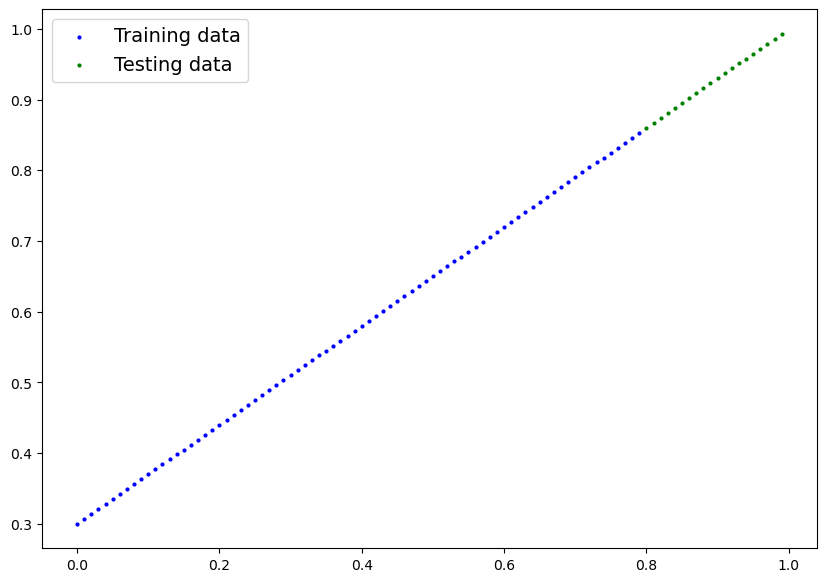

In [46]:
plot_predictions(X_tr, y_tr, X_tst, y_tst)

In [47]:
model_s = nn.Sequential(
    nn.Linear(in_features=1, out_features=10),
    nn.Linear(in_features=10, out_features=10),
    nn.Linear(in_features=10, out_features=1),
).to(device)
model_s

Sequential(
  (0): Linear(in_features=1, out_features=10, bias=True)
  (1): Linear(in_features=10, out_features=10, bias=True)
  (2): Linear(in_features=10, out_features=1, bias=True)
)

In [48]:
loss_fn = nn.L1Loss()

optimizer = torch.optim.SGD(params=model_s.parameters(), lr=0.1)

In [49]:
epochs = 1000

X_tr = X_tr.to(device)
X_tst = X_tst.to(device)
y_tr = y_tr.to(device)
y_tst = y_tst.to(device)

for epoch in range(epochs):
    model_s.train()

    y_preds = model_s(X_tr)
    loss = loss_fn(y_preds, y_tr)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    if epoch % 100 == 0:
        # Testing
        model_s.eval()
        with torch.inference_mode():
            y_preds = model_s(X_tst)
            loss_tst = loss_fn(y_preds, y_tst)
        print(f"Epoch: {epoch} | Train Loss: {loss.item()} | Test Loss: {loss_tst.item()}")

Epoch: 0 | Train Loss: 0.12405075877904892 | Test Loss: 0.01920332945883274
Epoch: 100 | Train Loss: 0.06566246598958969 | Test Loss: 0.026569997891783714
Epoch: 200 | Train Loss: 0.09781371802091599 | Test Loss: 0.03594101592898369
Epoch: 300 | Train Loss: 0.0847393050789833 | Test Loss: 0.02196248434484005
Epoch: 400 | Train Loss: 0.06362339854240417 | Test Loss: 0.006924474146217108
Epoch: 500 | Train Loss: 0.05996701121330261 | Test Loss: 0.012212407775223255
Epoch: 600 | Train Loss: 0.06578409671783447 | Test Loss: 0.026059946045279503
Epoch: 700 | Train Loss: 0.06087857112288475 | Test Loss: 0.006890878081321716
Epoch: 800 | Train Loss: 0.07469029724597931 | Test Loss: 0.00676275510340929
Epoch: 900 | Train Loss: 0.04921228811144829 | Test Loss: 0.011305931024253368


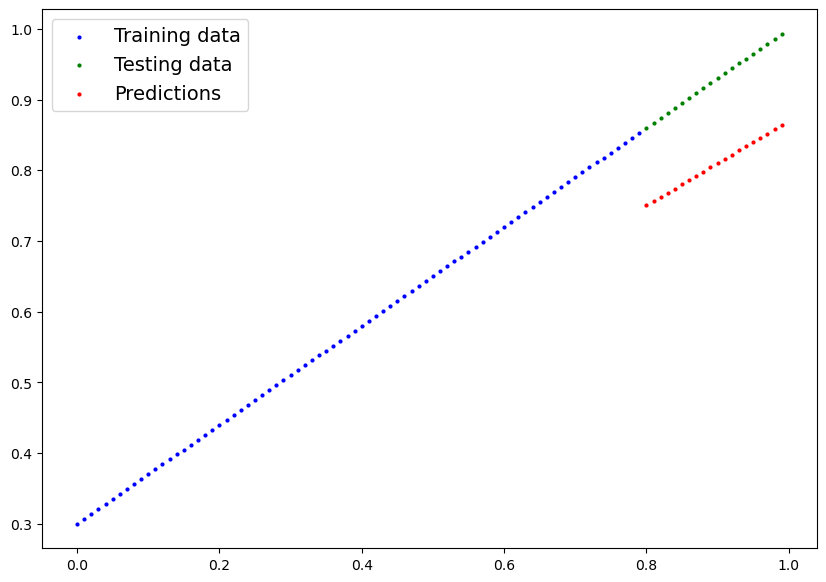

In [50]:
model_s.eval()
with torch.inference_mode():
    y_pred = model_s(X_tst)
plot_predictions(X_tr.to("cpu"), y_tr.to("cpu"), X_tst.to("cpu"), y_tst.to("cpu"), y_pred.to("cpu"))

## 6. The missing piece: Non-Linearity

"What patterns you could draw if you were given an infinite amount of a straight & non-straight lines?"

In ML it's actually just a finite amount (based on parameters)

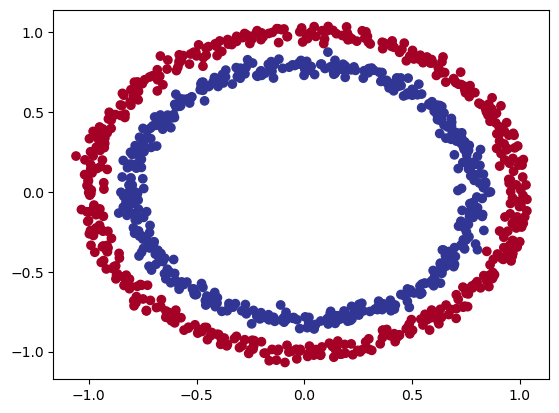

In [51]:
### 6.1 Recreating non-linear data i.e., circles

n_samples = 1000

X, y = make_circles(n_samples, noise=0.03, random_state=42)

plt.scatter(X[:, 0], X[:, 1], c=y, cmap=plt.cm.RdYlBu)

In [52]:
# Convert data to tensors & train test split
X = torch.from_numpy(X).type(torch.float)
y = torch.from_numpy(y).type(torch.float)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
len(X_train), len(y_train),len(X_test),len(y_test)

(800, 800, 200, 200)

### 6.2 Building the model with non-linearity

- Linear: Straight Lines
- Non-Linear: Non-Straight Lines

In [53]:
def test_activations(x):
    print(f"{x=} | {torch.sigmoid(x)=} | {torch.tanh(x)=} | {torch.relu(x)=}")

torch.manual_seed(189)
x = torch.randn(1)
test_activations(x)

y = torch.tensor([0.5])
test_activations(y)

z = torch.tensor([7])
test_activations(z)

z = torch.tensor([7000])
test_activations(z)

x=tensor([-0.6043]) | torch.sigmoid(x)=tensor([0.3534]) | torch.tanh(x)=tensor([-0.5401]) | torch.relu(x)=tensor([0.])
x=tensor([0.5000]) | torch.sigmoid(x)=tensor([0.6225]) | torch.tanh(x)=tensor([0.4621]) | torch.relu(x)=tensor([0.5000])
x=tensor([7]) | torch.sigmoid(x)=tensor([0.9991]) | torch.tanh(x)=tensor([1.0000]) | torch.relu(x)=tensor([7])
x=tensor([7000]) | torch.sigmoid(x)=tensor([1.]) | torch.tanh(x)=tensor([1.]) | torch.relu(x)=tensor([7000])


In [54]:
# Build a model with Non-Linear Activations
class CircleModelV2(nn.Module):
    def __init__(self):
        super().__init__()
        self.layer_1 = nn.Linear(in_features=2, out_features=10)
        self.layer_2 = nn.Linear(in_features=10, out_features=10)
        self.layer_3 = nn.Linear(in_features=10, out_features=1)
        self.relu = nn.ReLU() # non-linear actication function (element-wise)

    def forward(self, x):
        z = self.layer_1(x)
        z = self.relu(z)
        z = self.layer_2(z)
        z = self.relu(z)
        z = self.layer_3(z)
        return z

In [55]:
model_3 = CircleModelV2().to(device)
model_3, next(model_3.parameters()).device

(CircleModelV2(
   (layer_1): Linear(in_features=2, out_features=10, bias=True)
   (layer_2): Linear(in_features=10, out_features=10, bias=True)
   (layer_3): Linear(in_features=10, out_features=1, bias=True)
   (relu): ReLU()
 ),
 device(type='cuda', index=0))

In [56]:
model_3.state_dict()

OrderedDict([('layer_1.weight',
              tensor([[ 0.5302,  0.3259],
                      [ 0.1405, -0.5332],
                      [-0.4377, -0.2646],
                      [-0.6868,  0.2488],
                      [-0.1661, -0.3278],
                      [-0.6244, -0.2400],
                      [-0.5312,  0.6294],
                      [ 0.6618,  0.1551],
                      [-0.0043,  0.0104],
                      [ 0.2274, -0.4598]], device='cuda:0')),
             ('layer_1.bias',
              tensor([-2.5076e-04, -2.1593e-01, -2.4566e-01,  6.5033e-01, -2.6555e-01,
                       4.0399e-01, -3.9243e-02,  6.8859e-01,  3.2686e-01, -8.6109e-02],
                     device='cuda:0')),
             ('layer_2.weight',
              tensor([[-1.4052e-01,  1.8110e-01,  2.9566e-03,  1.6491e-01,  1.9515e-04,
                       -1.0817e-01, -2.0967e-01,  7.6793e-03, -4.9094e-02,  2.7165e-01],
                      [ 2.9794e-01, -1.0503e-01, -2.9261e-01, -1.5189e-01,

In [57]:
loss_fn = nn.BCEWithLogitsLoss()

optimizer = torch.optim.SGD(params=model_3.parameters(), lr=0.1)

loss_fn, optimizer

(BCEWithLogitsLoss(),
 SGD (
 Parameter Group 0
     dampening: 0
     differentiable: False
     foreach: None
     fused: None
     lr: 0.1
     maximize: False
     momentum: 0
     nesterov: False
     weight_decay: 0
 ))

In [58]:
X_train, y_train = X_train.to(device), y_train.to(device)
X_test, y_test = X_test.to(device), y_test.to(device)

In [59]:
epochs = 1500


epoch_count = []
train_losses = []
test_losses = []
train_accs = []
test_accs = []

for epoch in range(epochs):
    model_3.train()
    y_logits = model_3(X_train).squeeze()
    y_preds = torch.round(torch.sigmoid(y_logits)) # Logits -> Propabilities -> Labels
    loss = loss_fn(y_logits, y_train)
    acc = accuracy_fn(y_true=y_train, y_pred=y_preds)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    if epoch % 100 == 0:
        # Testing
        model_3.eval()
        with torch.inference_mode():
            y_logits = model_3(X_test).squeeze()
            y_preds = torch.round(torch.sigmoid(y_logits)) # Logits -> Propabilities -> Labels
        test_loss = loss_fn(y_logits, y_test)
        test_acc = accuracy_fn(y_true=y_test, y_pred=y_preds)

        epoch_count.append(epoch)
        train_losses.append(loss.item())
        test_losses.append(test_loss.item())
        train_accs.append(acc)
        test_accs.append(test_acc)
        
        print(f"Epoch: {epoch} | Loss: ({loss.item()}, {test_loss.item()}) | Accuracy: ({acc}, {test_acc})")

Epoch: 0 | Loss: (0.6903380155563354, 0.6907153129577637) | Accuracy: (54.87499999999999, 53.5)
Epoch: 100 | Loss: (0.686216413974762, 0.6871130466461182) | Accuracy: (60.12499999999999, 60.0)
Epoch: 200 | Loss: (0.6809819936752319, 0.6827806234359741) | Accuracy: (60.875, 60.5)
Epoch: 300 | Loss: (0.6727211475372314, 0.6759145855903625) | Accuracy: (67.375, 65.0)
Epoch: 400 | Loss: (0.658434271812439, 0.6642287373542786) | Accuracy: (72.75, 69.0)
Epoch: 500 | Loss: (0.6317741274833679, 0.6420354843139648) | Accuracy: (82.875, 78.0)
Epoch: 600 | Loss: (0.5788275599479675, 0.5986189842224121) | Accuracy: (94.0, 88.0)
Epoch: 700 | Loss: (0.48205894231796265, 0.5187438726425171) | Accuracy: (96.0, 90.5)
Epoch: 800 | Loss: (0.34543657302856445, 0.3941987156867981) | Accuracy: (98.0, 94.0)
Epoch: 900 | Loss: (0.21372158825397491, 0.2643027901649475) | Accuracy: (99.0, 98.0)
Epoch: 1000 | Loss: (0.15276357531547546, 0.1928815096616745) | Accuracy: (99.5, 97.5)
Epoch: 1100 | Loss: (0.09374826

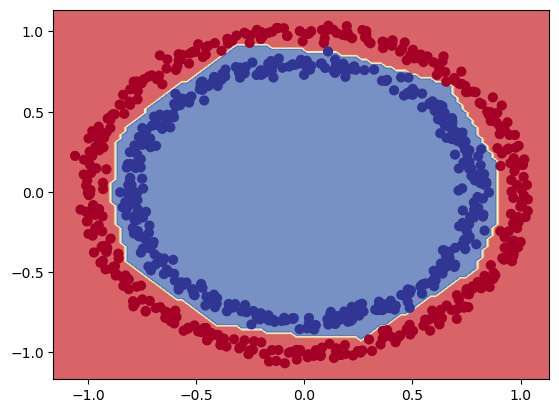

In [60]:
tmp = CircleModelV2()
tmp.load_state_dict(model_3.state_dict())
plot_decision_boundary(tmp, X_train, y_train)

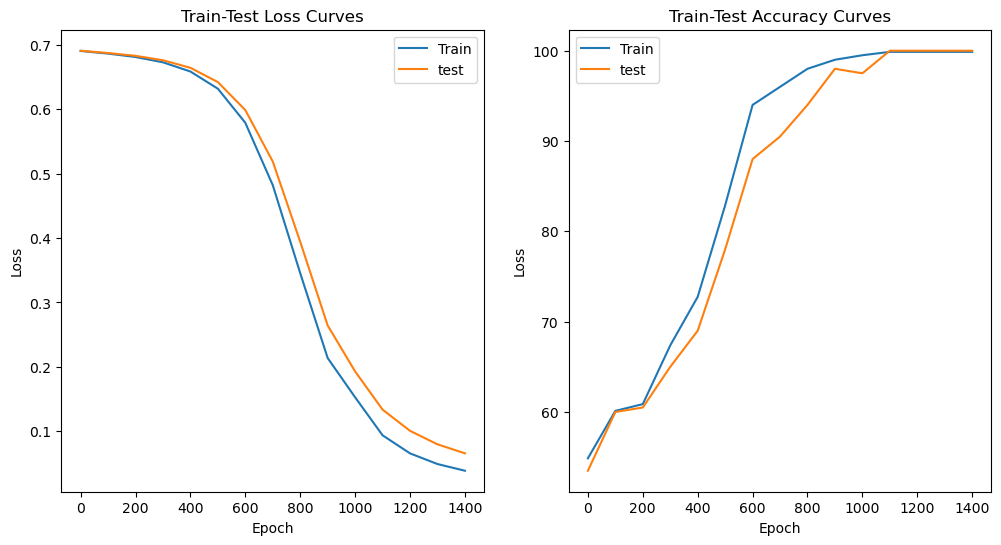

In [61]:
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.plot(epoch_count, train_losses, label="Train")
plt.plot(epoch_count, test_losses, label="test")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Train-Test Loss Curves")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(epoch_count, train_accs, label="Train")
plt.plot(epoch_count, test_accs, label="test")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Train-Test Accuracy Curves")
plt.legend()
plt.show();

plt.show();

## Fun Experiment :)

In [95]:
model_4 = nn.Sequential(
    nn.Linear(in_features=2, out_features=16),
    nn.Linear(in_features=16, out_features=8),
    nn.Linear(in_features=8, out_features=4),
    nn.Linear(in_features=4, out_features=2),
    nn.Linear(in_features=2, out_features=1),
)
model_4.to(device)
loss_fn = nn.BCEWithLogitsLoss()
optimizer = torch.optim.SGD(params=model_4.parameters(), lr=0.1)

In [96]:
epochs = 1500

for epoch in range(epochs):
    model_4.train()
    y_logits = model_4(X_train).squeeze()
    y_preds = torch.round(torch.sigmoid(y_logits)) # Logits -> Propabilities -> Labels
    loss = loss_fn(y_logits, y_train)
    acc = accuracy_fn(y_true=y_train, y_pred=y_preds)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    if epoch % 100 == 0:
        # Testing
        model_4.eval()
        with torch.inference_mode():
            y_logits = model_4(X_test).squeeze()
            y_preds = torch.round(torch.sigmoid(y_logits)) # Logits -> Propabilities -> Labels
        test_loss = loss_fn(y_logits, y_test)
        test_acc = accuracy_fn(y_true=y_test, y_pred=y_preds)
        
        print(f"Epoch: {epoch} | Loss: ({loss.item()}, {test_loss.item()}) | Accuracy: ({acc}, {test_acc})")

Epoch: 0 | Loss: (0.7176287174224854, 0.7162296175956726) | Accuracy: (50.0, 50.0)
Epoch: 100 | Loss: (0.6932640075683594, 0.693243682384491) | Accuracy: (50.0, 50.0)
Epoch: 200 | Loss: (0.693149983882904, 0.6931405663490295) | Accuracy: (50.0, 50.0)
Epoch: 300 | Loss: (0.6931489706039429, 0.6931425333023071) | Accuracy: (50.375, 49.5)
Epoch: 400 | Loss: (0.6931483149528503, 0.6931449174880981) | Accuracy: (50.24999999999999, 46.5)
Epoch: 500 | Loss: (0.6931477785110474, 0.6931474208831787) | Accuracy: (50.125, 48.0)
Epoch: 600 | Loss: (0.6931472420692444, 0.693149983882904) | Accuracy: (50.5, 49.0)
Epoch: 700 | Loss: (0.6931466460227966, 0.693152666091919) | Accuracy: (49.625, 51.5)
Epoch: 800 | Loss: (0.6931460499763489, 0.6931555867195129) | Accuracy: (49.625, 51.5)
Epoch: 900 | Loss: (0.6931452751159668, 0.6931586265563965) | Accuracy: (49.75, 51.5)
Epoch: 1000 | Loss: (0.693144679069519, 0.6931620836257935) | Accuracy: (49.625, 51.5)
Epoch: 1100 | Loss: (0.6931437253952026, 0.6931

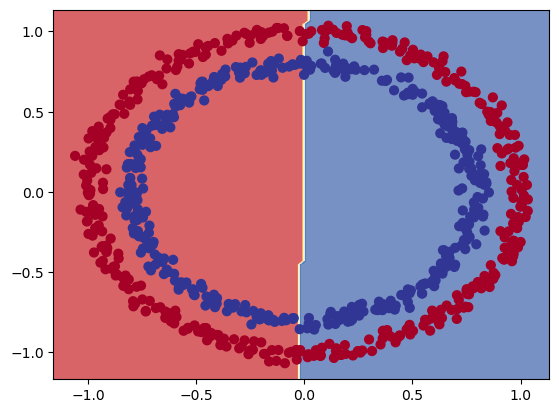

In [97]:
plot_decision_boundary(model_4, X_train, y_train)

In [101]:
model_5 = nn.Sequential(
    nn.Linear(in_features=2, out_features=10),
    nn.ReLU(),
    nn.Linear(in_features=10, out_features=10),
    nn.ReLU(),
    nn.Linear(in_features=10, out_features=1),
)
model_5.to(device)
loss_fn = nn.BCEWithLogitsLoss()
optimizer = torch.optim.SGD(params=model_5.parameters(), lr=0.1)

In [102]:
epochs = 15000

for epoch in range(epochs):
    model_5.train()
    y_logits = model_5(X_train).squeeze()
    y_preds = torch.round(torch.sigmoid(y_logits)) # Logits -> Propabilities -> Labels
    loss = loss_fn(y_logits, y_train)
    acc = accuracy_fn(y_true=y_train, y_pred=y_preds)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    if epoch % 1000 == 0:
        # Testing
        model_5.eval()
        with torch.inference_mode():
            y_logits = model_5(X_test).squeeze()
            y_preds = torch.round(torch.sigmoid(y_logits)) # Logits -> Propabilities -> Labels
        test_loss = loss_fn(y_logits, y_test)
        test_acc = accuracy_fn(y_true=y_test, y_pred=y_preds)
        
        print(f"Epoch: {epoch} | Loss: ({loss.item()}, {test_loss.item()}) | Accuracy: ({acc}, {test_acc})")

Epoch: 0 | Loss: (0.6936669945716858, 0.694020688533783) | Accuracy: (50.0, 50.0)
Epoch: 1000 | Loss: (0.6915926933288574, 0.6932041645050049) | Accuracy: (53.37499999999999, 48.5)
Epoch: 2000 | Loss: (0.6450245380401611, 0.6496898531913757) | Accuracy: (64.25, 61.5)
Epoch: 3000 | Loss: (0.10183431208133698, 0.1573689877986908) | Accuracy: (98.75, 96.5)
Epoch: 4000 | Loss: (0.035626430064439774, 0.09825444966554642) | Accuracy: (99.625, 97.0)
Epoch: 5000 | Loss: (0.024598026648163795, 0.09354445338249207) | Accuracy: (99.625, 97.5)
Epoch: 6000 | Loss: (0.020587170496582985, 0.09534181654453278) | Accuracy: (99.625, 97.5)
Epoch: 7000 | Loss: (0.018499745056033134, 0.0981844887137413) | Accuracy: (99.625, 97.5)
Epoch: 8000 | Loss: (0.017217613756656647, 0.1014067754149437) | Accuracy: (99.625, 97.5)
Epoch: 9000 | Loss: (0.01635243184864521, 0.10464891046285629) | Accuracy: (99.625, 97.5)
Epoch: 10000 | Loss: (0.015733627602458, 0.10775924474000931) | Accuracy: (99.625, 97.5)
Epoch: 11000

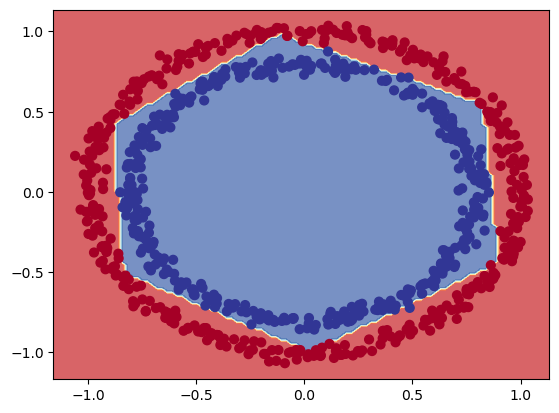

In [103]:
plot_decision_boundary(model_5, X_train, y_train)

## Replicating Non-Linear Activation Functions

In NN we can't tell the model what to learn rather we provide it with tools for discovering the patterns in data on it's own.

These tools include: Linear & Non-Linear Functions 

In [104]:
A = torch.arange(-10, 10, 1, dtype=torch.float32)
A

tensor([-10.,  -9.,  -8.,  -7.,  -6.,  -5.,  -4.,  -3.,  -2.,  -1.,   0.,   1.,
          2.,   3.,   4.,   5.,   6.,   7.,   8.,   9.])

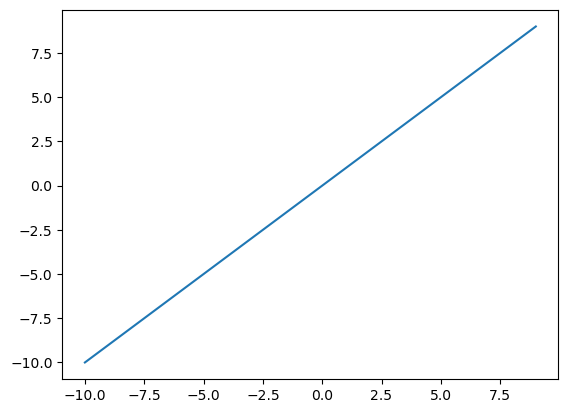

In [115]:
# Visualize
plt.plot(A, A);

In [108]:
torch.relu(A)

tensor([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 2., 3., 4., 5., 6., 7.,
        8., 9.])

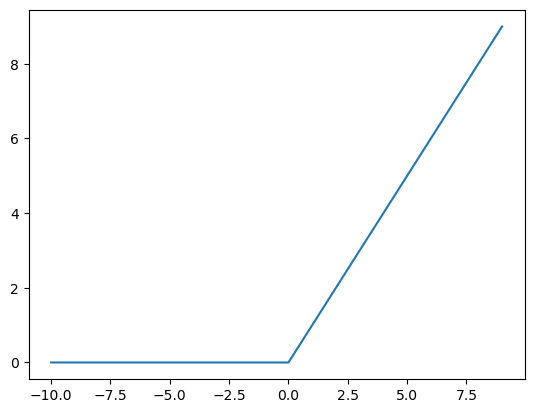

In [116]:
plt.plot(A, torch.relu(A))

In [110]:
def relu(x):
    return torch.max(torch.tensor(0), x)

In [111]:
relu(A)

tensor([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 2., 3., 4., 5., 6., 7.,
        8., 9.])

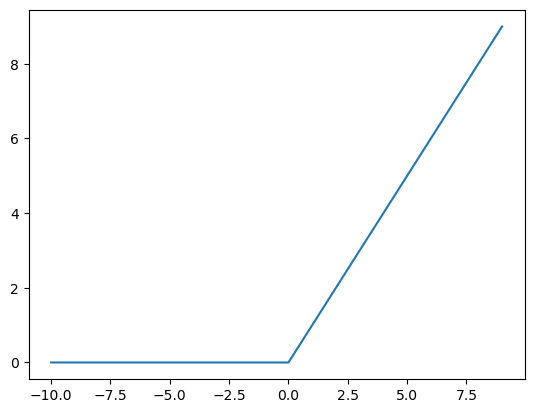

In [117]:
plt.plot(A, relu(A))

In [113]:
torch.sigmoid(A)

tensor([4.5398e-05, 1.2339e-04, 3.3535e-04, 9.1105e-04, 2.4726e-03, 6.6929e-03,
        1.7986e-02, 4.7426e-02, 1.1920e-01, 2.6894e-01, 5.0000e-01, 7.3106e-01,
        8.8080e-01, 9.5257e-01, 9.8201e-01, 9.9331e-01, 9.9753e-01, 9.9909e-01,
        9.9966e-01, 9.9988e-01])

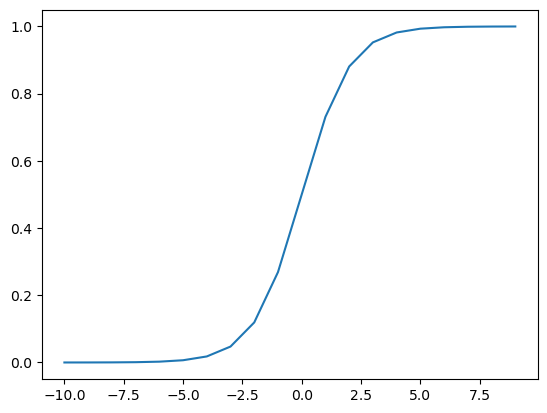

In [118]:
plt.plot(A, torch.sigmoid(A))

In [121]:
def sigmoid(x):
    return 1 / (1 + torch.exp(-x))

In [122]:
sigmoid(A)

tensor([4.5398e-05, 1.2339e-04, 3.3535e-04, 9.1105e-04, 2.4726e-03, 6.6929e-03,
        1.7986e-02, 4.7426e-02, 1.1920e-01, 2.6894e-01, 5.0000e-01, 7.3106e-01,
        8.8080e-01, 9.5257e-01, 9.8201e-01, 9.9331e-01, 9.9753e-01, 9.9909e-01,
        9.9966e-01, 9.9988e-01])

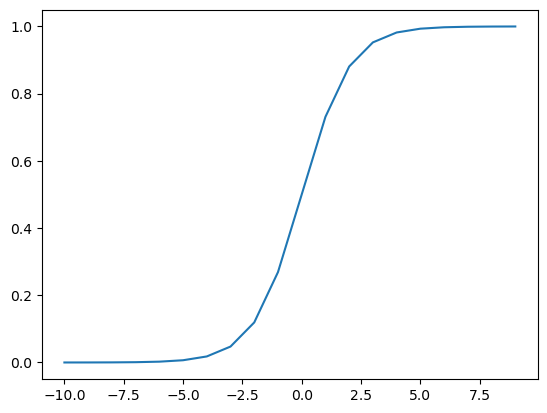

In [123]:
plt.plot(A, sigmoid(A))

In [127]:
def relu6(x):
    return torch.min(torch.tensor(6), torch.max(torch.tensor(0), x))

In [128]:
relu6(A)

tensor([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 2., 3., 4., 5., 6., 6.,
        6., 6.])

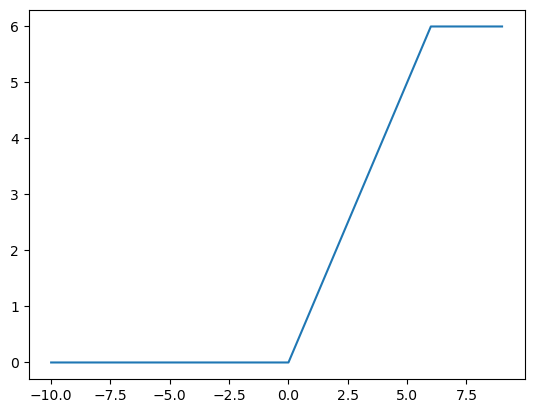

In [129]:
plt.plot(A, relu6(A))